# Zeros de Funções


### Bibliotecas

In [1]:
import numpy as np
import numpy as np
import sympy as sp
from sympy.parsing.sympy_parser import (parse_expr, standard_transformations, 
                                        implicit_multiplication_application, convert_xor)

In [2]:
import utils
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')  # ou 'seaborn-v0_8', 'fivethirtyeight'

In [3]:
import sympy as sp
from sympy.parsing.sympy_parser import (parse_expr, standard_transformations, 
                                        implicit_multiplication_application, convert_xor)

def ler_parametros_arquivo(nome_arquivo):
    """
    Lê os parâmetros do método da bissecção de um arquivo .txt.
    Formato esperado: funcao \\ limite_inferior \\ limite_superior \\ tolerancia \\ max_iteracoes
    
    Parâmetros:
    nome_arquivo (str): Caminho para o arquivo .txt.
    
    Retorna:
    tuple: (funcao_lambda, a, b, tol, max_iter)
    """
    try:
        with open(nome_arquivo, 'r') as arquivo:
            conteudo = arquivo.read().strip()
            
        print(f"Conteúdo do arquivo: {conteudo}")
        
        # Separa os parâmetros pelo delimitador '\'
        partes = [p.strip() for p in conteudo.split('\\')]
        
        if len(partes) != 5:
            print("Erro: O arquivo deve conter 5 parâmetros separados por '\\'.")
            print("Formato: funcao \\ a \\ b \\ tol \\ max_iter")
            return None

        str_funcao, str_a, str_b, str_tol, str_max_iter = partes

        # 1. Processa a função com SymPy
        transformations = (standard_transformations + 
                         (implicit_multiplication_application,) + 
                         (convert_xor,))
        
        expr = parse_expr(str_funcao, transformations=transformations)
        print(f"Função interpretada: {expr}")
        
        # TENTA identificar a variável. Se houver falha ou ambiguidade, padroniza como 'x'.
        simbolos = list(expr.free_symbols)
        if not simbolos:
             x = sp.symbols('x')
        else:
             # Ordena para ter consistência se houver mais de um, e pega o primeiro como principal
             x = sorted(simbolos, key=str)[0]

        # IMPORTANTE: Garante que a função retorne float nativo e não tipos do SymPy
        # 'numpy' no modules já deve cuidar disso para arrays, mas para escalares pode ser tricky.
        # Por segurança, vamos usar lambda que converte explicitamente.
        f_num = sp.lambdify(x, expr, modules=['numpy', 'math'])
        
        funcao = lambda val: float(f_num(val))
        
        # 2. Converte os outros parâmetros
        a = float(str_a)
        b = float(str_b)
        tol = float(str_tol)
        max_iter = int(str_max_iter)

        return funcao, a, b, tol, max_iter
        
    except FileNotFoundError:
        print(f"Erro: O arquivo '{nome_arquivo}' não foi encontrado.")
        return None
    except ValueError as e:
        print(f"Erro de conversão de tipos: {e}")
        return None
    except Exception as e:
        print(f"Erro ao processar o arquivo: {e}")
        return None

In [4]:
parametros = ler_parametros_arquivo('funcao.txt')

if parametros:
    funcao, a, b, tol, max_iter = parametros
    print("Função e parâmetros lidos com sucesso:")
    print(f"Intervalo: [{a}, {b}]")
    print(f"Tolerância: {tol}")
    print(f"Máximo de iterações: {max_iter}")
    
    # Testa a função nos limites do intervalo
    fa = funcao(a)
    fb = funcao(b)
    print(f"f({a}) = {fa}")
    print(f"f({b}) = {fb}")
else:
    print("Falha ao ler o arquivo.")

Conteúdo do arquivo: cos(pi*(x + 1)/8) + 0.148*x - 0.9062 \ -1.0 \ 0.0 \ 0.000001 \ 100
Função interpretada: 0.148*x + cos(pi*(x/8 + 1/8)) - 0.9062
Função e parâmetros lidos com sucesso:
Intervalo: [-1.0, 0.0]
Tolerância: 1e-06
Máximo de iterações: 100
f(-1.0) = -0.054200000000000026
f(0.0) = 0.017679532511286733


## Método da Bissecção


In [5]:
def bisseccao(funcao, a, b, tol=1e-6, max_iter=100):
    historico = [] 
    
    for i in range(max_iter):
        c = (a + b)/2
        fc = funcao(c)
        denominador = a + b

        if denominador != 0:
            er = abs((a - b) / denominador)
        else:
            er = abs(b - a) # Se o denominador for zero, usamos apenas o erro absoluto
        
        historico.append({
            'iter': i, 
            'a': a, 
            'b': b, 
            'c': c, 
            'f(c)': fc,
            'erro': er
        })

        # print(f"i={i}, a={a:.6f}, b={b:.6f}, c={c:.6f}, f(c)={fc:.6e}, erro={er * 100:.2f}%")
        
        if fc == 0 or er < tol:
            return c, i, historico
            
        # print(f"i={i}, a={a:.6f}, b={b:.6f}, c={c:.6f}, f(c)={fc:.6e}")
            
        if utils.teorema_bolzano(funcao, a, c):
            b = c
        else:
            a = c
            
    return c, max_iter, historico

In [6]:
c, i, historico_biss = bisseccao(funcao, a, b, tol, max_iter)
print(f"Raiz aproximada encontrada: {c}")
print(f"Número de iterações: {i}")

Raiz aproximada encontrada: -0.5081286430358887
Número de iterações: 20


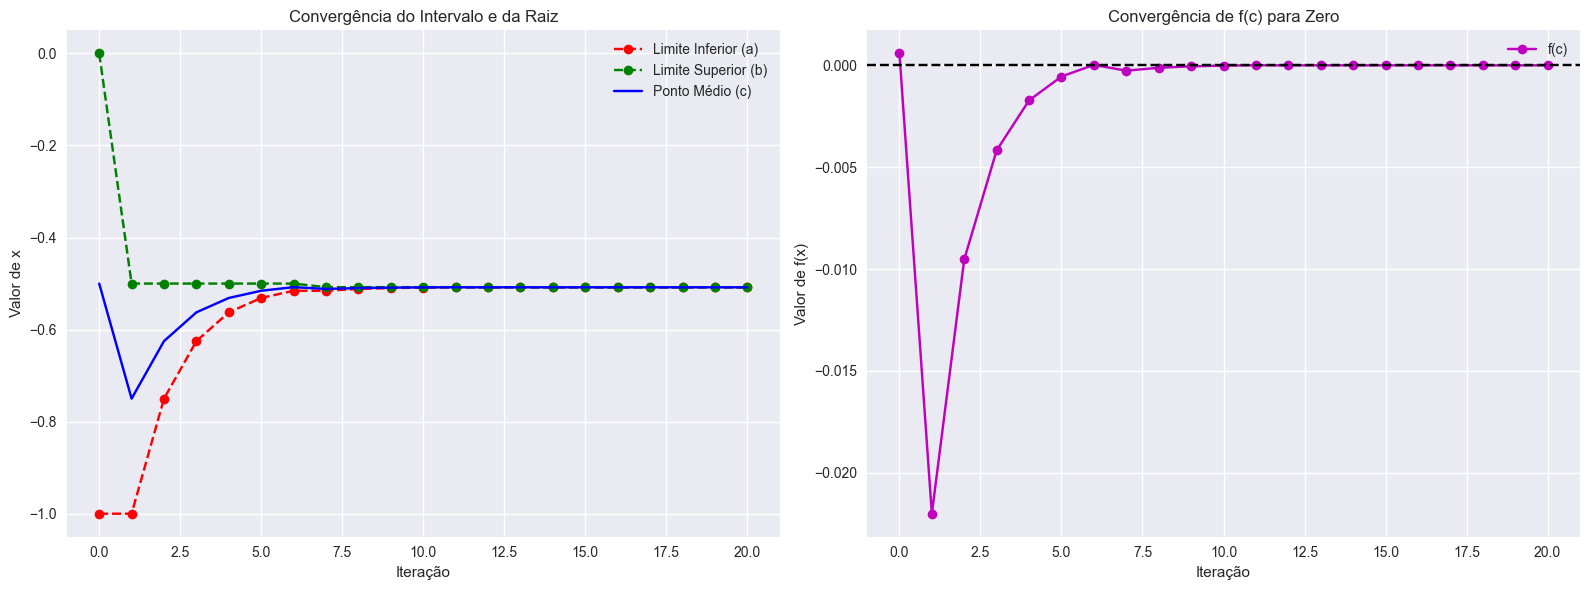

In [7]:
def plotar_convergencia(historico):
    if not historico:
        print("Nenhuma iteração foi realizada.")
        return

    iteracoes = [d['iter'] for d in historico]
    a_vals = [d['a'] for d in historico]
    b_vals = [d['b'] for d in historico]
    c_vals = [d['c'] for d in historico]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Gráfico 1: Convergência dos Intervalos [a, b]
    ax1.plot(iteracoes, a_vals, 'r--o', label='Limite Inferior (a)')
    ax1.plot(iteracoes, b_vals, 'g--o', label='Limite Superior (b)')
    ax1.plot(iteracoes, c_vals, 'b-x', label='Ponto Médio (c)')
    ax1.set_title('Convergência do Intervalo e da Raiz')
    ax1.set_xlabel('Iteração')
    ax1.set_ylabel('Valor de x')
    ax1.grid(True)
    ax1.legend()

    # Gráfico 2: Comportamento de f(c) - Convergência para zero
    f_vals = [d['f(c)'] for d in historico]
    ax2.plot(iteracoes, f_vals, 'm-o', label='f(c)')
    ax2.axhline(0, color='black', linestyle='--')
    ax2.set_title('Convergência de f(c) para Zero')
    ax2.set_xlabel('Iteração')
    ax2.set_ylabel('Valor de f(x)')
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.show()

if 'historico_biss' in locals():
    plotar_convergencia(historico_biss)
else:
    print("Execute o método da bissecção primeiro para gerar o histórico.")

## 

In [8]:
def posicaoFalsa(funcao, a, b, tol=1e-6, max_iter=100):
    historico = [] 
    
    for i in range(max_iter):
        c_an = historico[-1]['c'] if historico else a  
        c = b - (funcao(b) * (a - b)) / (funcao(a) - funcao(b))
        fc = funcao(c)

        er = abs(c - c_an) / c if c != 0 else 0
       
        historico.append({
            'iter': i, 
            'a': a, 
            'b': b, 
            'c': c, 
            'f(c)': fc,
            'erro': er
        })

        # print(f"i={i}, a={a:.6f}, b={b:.6f}, c={c:.6f}, f(c)={fc:.6e}, erro={er * 100:.2f}%")
        
        if fc == 0 or er < tol:
            return c, i, historico
            
            
        if utils.teorema_bolzano(funcao, a, c):
            b = c
        else:
            a = c
            
    return c, max_iter, historico

Raiz aproximada encontrada: -0.24596059397729994
Número de iterações: 0


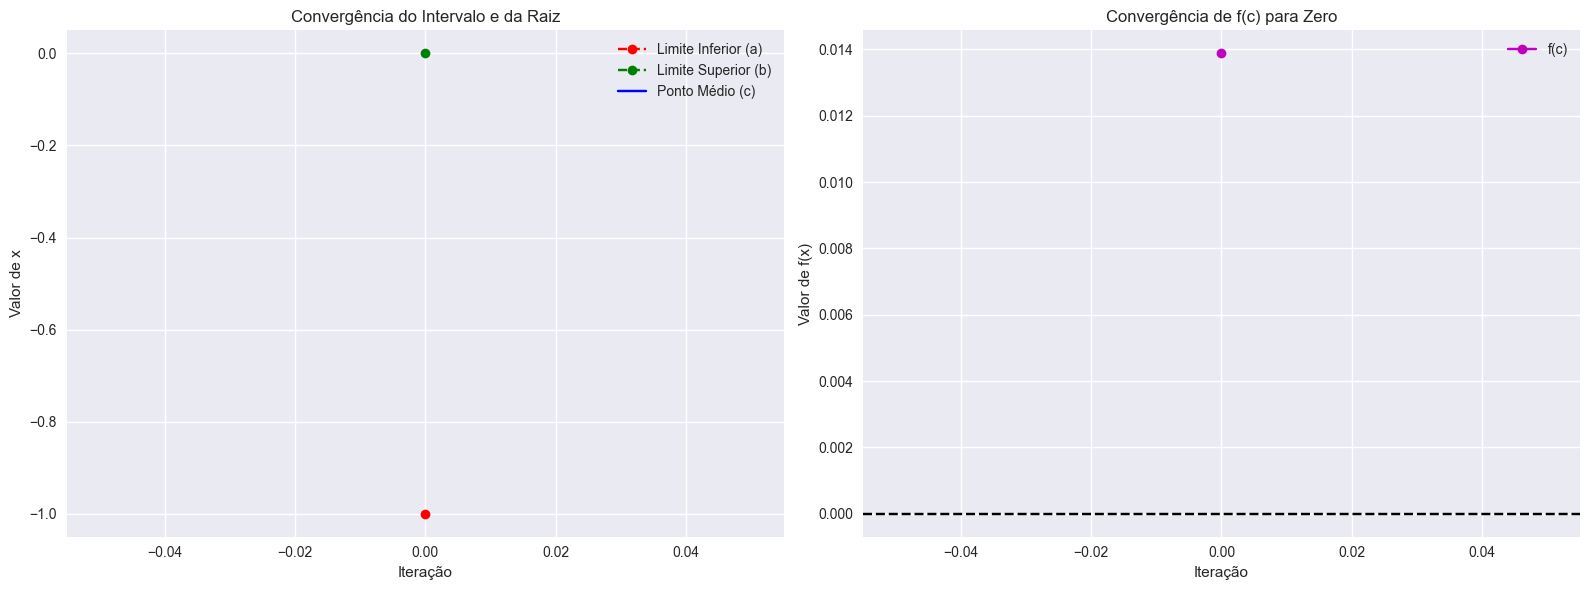

In [9]:
c_fpos, i, historico_PosFals = posicaoFalsa(funcao, a, b, tol, max_iter)
print(f"Raiz aproximada encontrada: {c_fpos}")
print(f"Número de iterações: {i}")
plotar_convergencia(historico_PosFals)


In [10]:
import pandas as pd

# Executa os métodos novamente para garantir dados frescos
root_bis, iter_bis, hist_bis = bisseccao(funcao, a, b, tol, max_iter)
root_pos, iter_pos, hist_pos = posicaoFalsa(funcao, a, b, tol, max_iter)

# Monta os dados para a tabela
dados_comparacao = {
    "Método": ["Bissecção", "Posição Falsa"],
    "Raiz Aprox.": [root_bis, root_pos],
    "Iterações": [iter_bis, iter_pos],
    "Erro Final (%)": [hist_bis[-1]['erro']*100, hist_pos[-1]['erro']*100],
    "f(Raiz)": [hist_bis[-1]['f(c)'], hist_pos[-1]['f(c)']]
}

# Cria o DataFrame
df = pd.DataFrame(dados_comparacao)

# Exibe a tabela
print("Comparação de Desempenho:")
display(df)

# Exibe o código LaTeX da tabela
print("\nCódigo LaTeX da Tabela:")
print(df.to_latex(index=True, float_format="%.6f", caption="Comparação de Desempenho entre Bissecção e Posição Falsa", label="tab:comparacao_desempenho"))

Comparação de Desempenho:


,Método,Raiz Aprox.,Iterações,Erro Final (%),f(Raiz)
0,Bissecção,-0.508129,20,0.000094,-6.814057e-09
1,Posição Falsa,-0.245961,0,-306.569192,1.387649e-02



Código LaTeX da Tabela:
\begin{table}
\caption{Comparação de Desempenho entre Bissecção e Posição Falsa}
\label{tab:comparacao_desempenho}
\begin{tabular}{llrrrr}
\toprule
 & Método & Raiz Aprox. & Iterações & Erro Final (%) & f(Raiz) \\
\midrule
0 & Bissecção & -0.508129 & 20 & 0.000094 & -0.000000 \\
1 & Posição Falsa & -0.245961 & 0 & -306.569192 & 0.013876 \\
\bottomrule
\end{tabular}
\end{table}

